In [1]:
# install firedrake

# hide output
%%capture


try:
    from firedrake import *
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    from firedrake import *

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Patrick's Code

In [3]:
from firedrake import *

N = 4
mesh = SquareMesh(N, N, pi, quadrilateral=False)  # like Fig 3.22

# Should I use Nédélec elements, or Lagrange?
hcurl = False

if hcurl:
    Z = FunctionSpace(mesh, "N1curl", 1)
else:
    Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# This only imposes tangential zero component: Firedrake enforces
# unknown·t = bcdata·t
# for H(curl) function spaces
if hcurl:
    bc = [DirichletBC(Z, Constant((0, 0)), "on_boundary")]
else:
    bc = [DirichletBC(Z.sub(0), 0, (3, 4)),
          DirichletBC(Z.sub(1), 0, (1, 2))]

# Scalar rot
def rot_s(E):
    return E[1].dx(0) - E[0].dx(1)

E = TrialFunction(Z)
F = TestFunction(Z)

a = inner(rot_s(E), rot_s(F))*dx
b = inner(E, F)*dx

problem = LinearEigenproblem(a, b, bcs=bc, restrict=True)
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }
solver = LinearEigensolver(problem, n_evals=50, solver_parameters=sp)

nconv = solver.solve()
eigs = sorted(solver.eigenvalue(i) for i in range(nconv))
for (i, eig) in enumerate(eigs):
    print(BLUE % f"{i:02d} ω²: {eig:.14e}")

  Eigenvalue approximations and residual norms for petsctools_1_ solve.
00 ω²: -5.10702591327572e-15
01 ω²: 2.44249065417534e-15
02 ω²: 4.66293670342566e-15
03 ω²: 2.85592753843783e-01
04 ω²: 5.90333221219484e-01
05 ω²: 6.79540980374944e-01
06 ω²: 7.47064011620181e-01
07 ω²: 7.75201975335959e-01
08 ω²: 1.05246145863534e+00
09 ω²: 1.05413760467427e+00
10 ω²: 2.14591856349089e+00
11 ω²: 2.44774807538279e+00
12 ω²: 4.03725260370563e+00
13 ω²: 4.04300209501191e+00
14 ω²: 4.85050644857734e+00
15 ω²: 4.97955858077311e+00
16 ω²: 5.80268805987405e+00
17 ω²: 6.33785897290139e+00
18 ω²: 6.54838599415266e+00
19 ω²: 9.77688442328386e+00
20 ω²: 1.26183360275717e+01
21 ω²: 1.30215694675164e+01
22 ω²: 1.38825649656100e+01
23 ω²: 1.44098781058373e+01
24 ω²: 1.54636677611099e+01
25 ω²: 1.63937028121320e+01
26 ω²: 1.78207578274134e+01
27 ω²: 2.34556289217467e+01
28 ω²: 2.49240471438433e+01
29 ω²: 3.23210414755931e+01


# My Code - CG1

  Eigenvalue approximations and residual norms for petsctools_3_ solve.


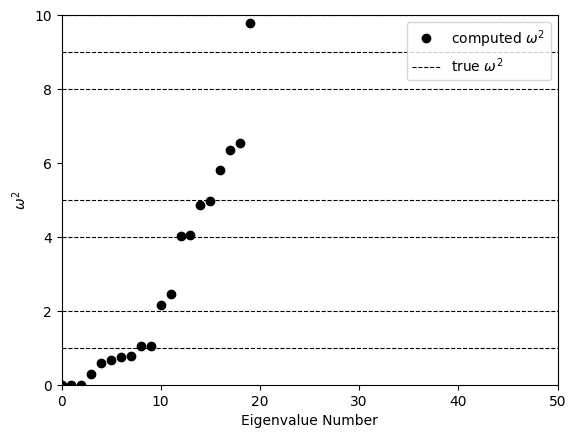

In [4]:
# Set the structured square mesh on (0, pi)
N = 4
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
# plt.title(r"$N=4$")
plt.legend()
plt.savefig('Maxwell_CG1_N4.png', dpi=300, bbox_inches="tight")
plt.show()



  Eigenvalue approximations and residual norms for petsctools_5_ solve.


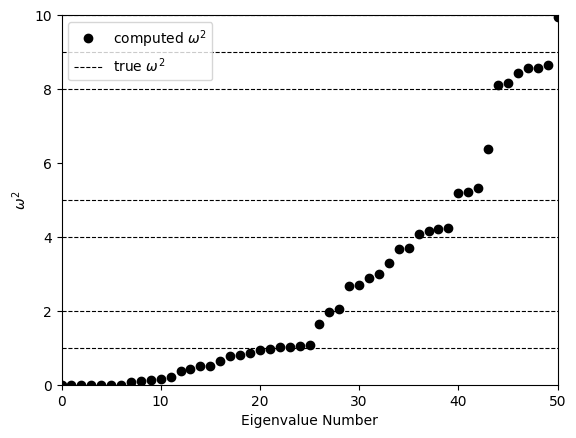

In [5]:
# Set the structured square mesh on (0, pi)
N = 8
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
# plt.title(r"$N=8$")
plt.legend()
plt.savefig('Maxwell_CG1_N8.png', dpi=300, bbox_inches="tight")
plt.show()

  Eigenvalue approximations and residual norms for petsctools_7_ solve.
  1 EPS nconv=133 first unconverged value (error) 10.8822 (1.13215641e-10)


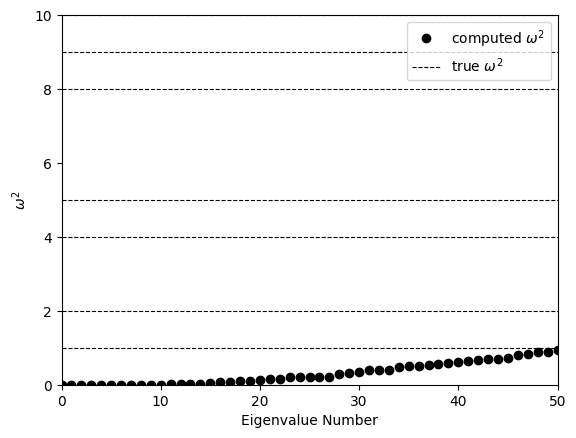

In [6]:
# Set the structured square mesh on (0, pi)
N = 16
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)

# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
# plt.title(r"$N=16$")
plt.legend()
plt.savefig('Maxwell_CG1_N16.png', dpi=300, bbox_inches="tight")
plt.show()

# My Code - CG1 Criss-Cross

In [7]:
eigvals = []

Full DOFs: 82
Constrained DOFs: 20
Free DOFs: 62
  Eigenvalue approximations and residual norms for petsctools_9_ solve.


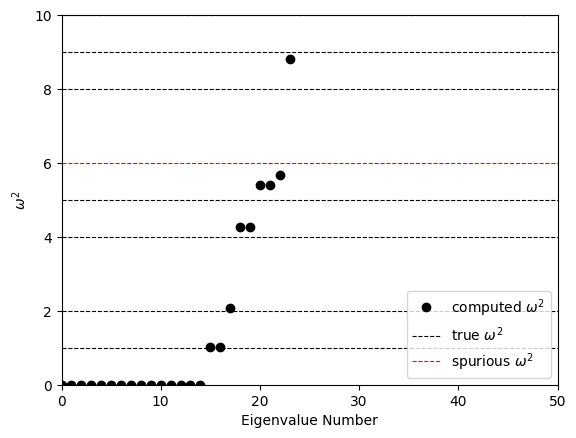

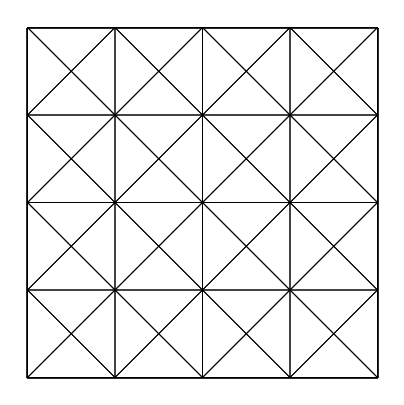

In [8]:
# Set the structured square mesh on (0, pi)
N = 4
mesh = SquareMesh(N, N, pi, diagonal = "crossed")

# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)


# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Degrees of freedom
full_dofs = Z.dim()
constrained_dofs = sum(len(bc.nodes) for bc in bcs)
free_dofs = full_dofs - constrained_dofs
print("Full DOFs:", full_dofs)
print("Constrained DOFs:", constrained_dofs)
print("Free DOFs:", free_dofs)

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))
eigvals.append(eigs)

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.axhline(6, linestyle="--", linewidth=0.8, color = 'r', label = r"spurious $\omega^2$")
# plt.title(r"$N=4$")
plt.legend(loc='lower right')
plt.savefig('CrissCross_CG1_N4.png', dpi=300, bbox_inches="tight")
plt.show()

# Triplot the mesh
nmarkers = len(mesh.exterior_facets.unique_markers)
fig, ax = plt.subplots(figsize=(5, 5))
triplot(mesh, axes=ax, \
        interior_kw={"edgecolors": "black","linewidths": 0.7}, \
        boundary_kw={"colors": ["black"] * nmarkers,"linewidths": 1.2},)
ax.set_aspect("equal")
ax.set_axis_off()
#ax.set_title(rf"Criss-cross mesh on $(0,\pi)^2$, $N={N}$")
#ax.set_xlabel(r"$x$")
#ax.set_ylabel(r"$y$")
plt.savefig("crisscross_mesh_N4.png", dpi=300, bbox_inches="tight")
plt.show()


Full DOFs: 290
Constrained DOFs: 36
Free DOFs: 254
  Eigenvalue approximations and residual norms for petsctools_11_ solve.
  1 EPS nconv=31 first unconverged value (error) -0.0039482 (6.30439444e-02)
  2 EPS nconv=47 first unconverged value (error) -0.679677 (8.29274412e-01)
  3 EPS nconv=136 first unconverged value (error) 81.9185 (6.27492107e-05)


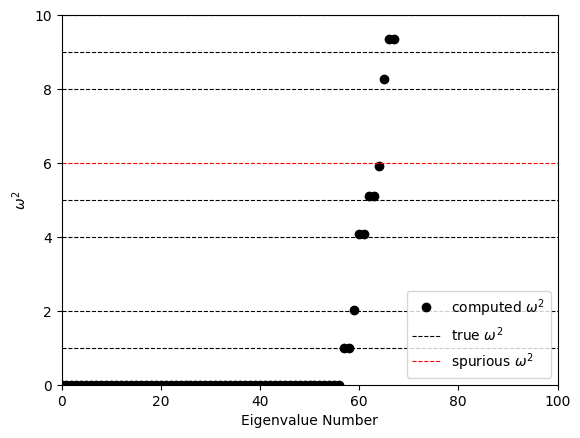

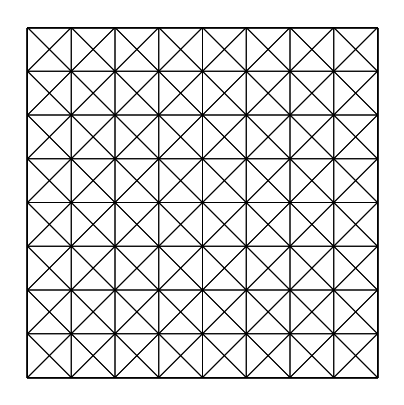

In [9]:
# Set the structured square mesh on (0, pi)
N = 8
mesh = SquareMesh(N, N, pi, diagonal = "crossed")


# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)


# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Degrees of freedom
full_dofs = Z.dim()
constrained_dofs = sum(len(bc.nodes) for bc in bcs)
free_dofs = full_dofs - constrained_dofs
print("Full DOFs:", full_dofs)
print("Constrained DOFs:", constrained_dofs)
print("Free DOFs:", free_dofs)

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))
eigvals.append(eigs)

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 100)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.axhline(6, linestyle="--", linewidth=0.8, color = 'r', label = r"spurious $\omega^2$")
# plt.title(r"$N=8$")
plt.legend(loc='lower right')
plt.savefig('CrissCross_CG1_N8.png', dpi=300, bbox_inches="tight")
plt.show()

# Triplot the mesh
# Triplot the mesh
fig, ax = plt.subplots(figsize=(5, 5))
triplot(mesh, axes=ax, \
        interior_kw={"edgecolors": "black","linewidths": 0.7}, \
        boundary_kw={"colors": ["black"] * nmarkers,"linewidths": 1.2},)
ax.set_aspect("equal")
ax.set_axis_off()
#ax.set_title(rf"Criss-cross mesh on $(0,\pi)^2$, $N={N}$")
#ax.set_xlabel(r"$x$")
#ax.set_ylabel(r"$y$")
plt.savefig("crisscross_mesh_N8.png", dpi=300, bbox_inches="tight")
plt.show()

Full DOFs: 1090
Constrained DOFs: 68
Free DOFs: 1022
  Eigenvalue approximations and residual norms for petsctools_13_ solve.
  1 EPS nconv=10 first unconverged value (error) 5.68434e-14 (1.64956384e-10)
  2 EPS nconv=124 first unconverged value (error) 76.7506 (4.32935413e-06)


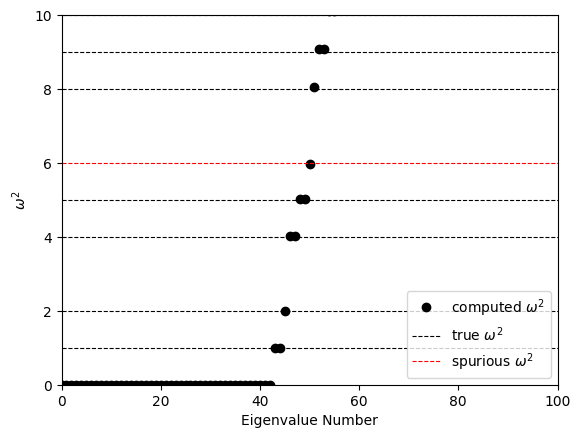

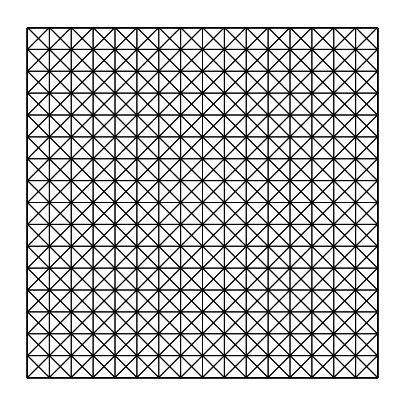

In [10]:
# Set the structured square mesh on (0, pi)
N = 16
mesh = SquareMesh(N, N, pi, diagonal = "crossed")


# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)


# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Degrees of freedom
full_dofs = Z.dim()
constrained_dofs = sum(len(bc.nodes) for bc in bcs)
free_dofs = full_dofs - constrained_dofs
print("Full DOFs:", full_dofs)
print("Constrained DOFs:", constrained_dofs)
print("Free DOFs:", free_dofs)

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)


# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))
eigvals.append(eigs)

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 100)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.axhline(6, linestyle="--", linewidth=0.8, color = 'r', label = r"spurious $\omega^2$")
# plt.title(r"$N=16$")
plt.legend(loc='lower right')
plt.savefig('CrissCross_CG1_N16.png', dpi=300, bbox_inches="tight")
plt.show()

# Triplot the mesh
fig, ax = plt.subplots(figsize=(5, 5))
triplot(mesh, axes=ax, \
        interior_kw={"edgecolors": "black","linewidths": 0.7}, \
        boundary_kw={"colors": ["black"] * nmarkers,"linewidths": 1.2},)
ax.set_aspect("equal")
ax.set_axis_off()
#ax.set_title(rf"Criss-cross mesh on $(0,\pi)^2$, $N={N}$")
#ax.set_xlabel(r"$x$")
#ax.set_ylabel(r"$y$")
plt.savefig("crisscross_mesh_N16.png", dpi=300, bbox_inches="tight")
plt.show()

Full DOFs: 4226
Constrained DOFs: 132
Free DOFs: 4094
  Eigenvalue approximations and residual norms for petsctools_15_ solve.
  1 EPS nconv=5 first unconverged value (error) 4.63185e-13 (1.87072181e-09)
  2 EPS nconv=120 first unconverged value (error) 69.2291 (1.55818639e-09)


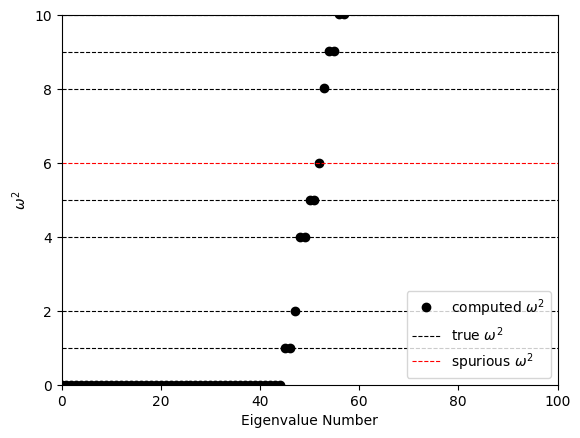

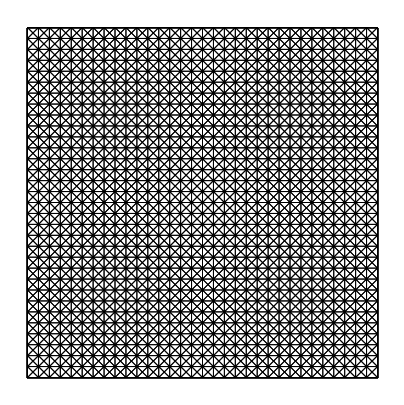

In [11]:
# Set the structured square mesh on (0, pi)
N = 32
mesh = SquareMesh(N, N, pi, diagonal = "crossed")



# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)


# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Degrees of freedom
full_dofs = Z.dim()
constrained_dofs = sum(len(bc.nodes) for bc in bcs)
free_dofs = full_dofs - constrained_dofs
print("Full DOFs:", full_dofs)
print("Constrained DOFs:", constrained_dofs)
print("Free DOFs:", free_dofs)

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))
eigvals.append(eigs)

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 100)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.axhline(6, linestyle="--", linewidth=0.8, color = 'r', label = r"spurious $\omega^2$")
# plt.title(r"$N=32$")
plt.legend(loc='lower right')
plt.savefig('CrissCross_CG1_N16.png', dpi=300, bbox_inches="tight")
plt.show()

# Triplot the mesh
fig, ax = plt.subplots(figsize=(5, 5))
triplot(mesh, axes=ax, \
        interior_kw={"edgecolors": "black","linewidths": 0.7}, \
        boundary_kw={"colors": ["black"] * nmarkers,"linewidths": 1.2},)
ax.set_aspect("equal")
ax.set_axis_off()
#ax.set_title(rf"Criss-cross mesh on $(0,\pi)^2$, $N={N}$")
#ax.set_xlabel(r"$x$")
#ax.set_ylabel(r"$y$")
plt.savefig("crisscross_mesh_N32.png", dpi=300, bbox_inches="tight")
plt.show()

DOF of Z: 16642

Full DOFs: 16642
Constrained DOFs: 260
Free DOFs: 16382
  Eigenvalue approximations and residual norms for petsctools_17_ solve.
  1 EPS nconv=96 first unconverged value (error) 61.2489 (7.04929379e-10)
  2 EPS nconv=124 first unconverged value (error) 80.4278 (1.03532699e-09)


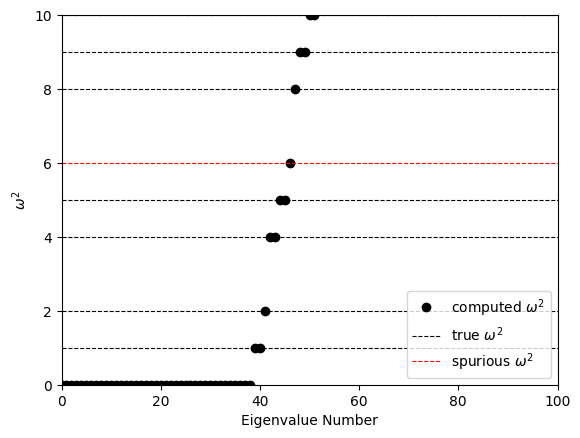

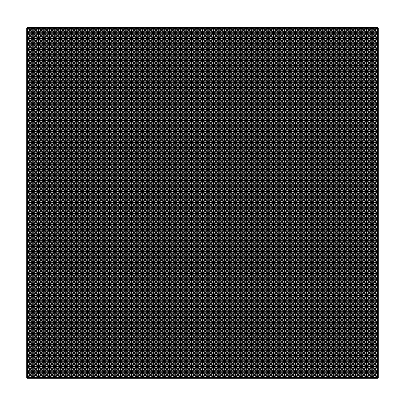

In [12]:
# Set the structured square mesh on (0, pi)
N = 64
mesh = SquareMesh(N, N, pi, diagonal = "crossed")



# Set the Lagrange space
Z = VectorFunctionSpace(mesh, "CG", 1, dim=2)
print('DOF of Z:', Z.dim())
print()


# Set zero tangential component
bc1 = DirichletBC(Z.sub(0), Constant(0), (3, 4)) # set Z_x = 0 on y=0 and y=pi
bc2 = DirichletBC(Z.sub(1), Constant(0), (1, 2)) # set Z_y = 0 on x=0 and x=pi
bcs = [bc1, bc2]

# Degrees of freedom
full_dofs = Z.dim()
constrained_dofs = sum(len(bc.nodes) for bc in bcs)
free_dofs = full_dofs - constrained_dofs
print("Full DOFs:", full_dofs)
print("Constrained DOFs:", constrained_dofs)
print("Free DOFs:", free_dofs)

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))
eigvals.append(eigs)

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 100)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
plt.axhline(6, linestyle="--", linewidth=0.8, color = 'r', label = r"spurious $\omega^2$")
# plt.title(r"$N=64$")
plt.legend(loc='lower right')
plt.savefig('CrissCross_CG1_N16.png', dpi=300, bbox_inches="tight")
plt.show()

# Triplot the mesh
fig, ax = plt.subplots(figsize=(5, 5))
triplot(mesh, axes=ax, \
        interior_kw={"edgecolors": "black","linewidths": 0.7}, \
        boundary_kw={"colors": ["black"] * nmarkers,"linewidths": 1.2},)
ax.set_aspect("equal")
ax.set_axis_off()
#ax.set_title(rf"Criss-cross mesh on $(0,\pi)^2$, $N={N}$")
#ax.set_xlabel(r"$x$")
#ax.set_ylabel(r"$y$")
plt.savefig("crisscross_mesh_N64.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# Print out the results

import pandas as pd

Ns = [4, 8, 16, 32, 64]

# Put the limiting / reference values you want shown in the last column.
# Adjust this list depending on what rows you want in the table.
targets = [1, 1, 2, 4, 4, 5, 5, 6, 8, 9, 9]

def match_to_targets(vals, targets):
    vals = np.sort(np.real(np.array(vals)))
    used = np.zeros(len(vals), dtype=bool)
    matched = []

    for t in targets:
        available = np.where(~used)[0]
        if len(available) == 0:
            matched.append(np.nan)
            continue

        j = available[np.argmin(np.abs(vals[available] - t))]
        matched.append(vals[j])
        used[j] = True

    return matched

data = {}

for N, vals in zip(Ns, eigvals):
    data[f"$N={N}$"] = match_to_targets(vals, targets)

data[r"$\cdots$"] = [r"$\cdots$"] * len(targets)
data[r"$N=\infty$"] = targets

df = pd.DataFrame(data)

# Optional row labels
df.index = [r"$1$", r"$1$", r"$2$", r"$4$", r"$4$", r"$5$", r"$5$", r"$6$", r"$8$", r"$9$", r"$9$" ]

print(df)

         $N=4$     $N=8$    $N=16$    $N=32$    $N=64$  $\cdots$  $N=\infty$
$1$   1.017010  1.004276  1.001070  1.000268  1.000067  $\cdots$           1
$1$   1.017010  1.004276  1.001070  1.000268  1.000067  $\cdots$           1
$2$   2.067822  2.017113  2.004283  2.001071  2.000268  $\cdots$           2
$4$   4.264703  4.068039  4.017105  4.004282  4.001071  $\cdots$           4
$4$   4.264703  4.068039  4.017105  4.004282  4.001071  $\cdots$           4
$5$   5.397073  5.106342  5.026739  5.006691  5.001673  $\cdots$           5
$5$   5.397073  5.106342  5.026739  5.006691  5.001673  $\cdots$           5
$6$   5.671192  5.922934  5.980743  5.995182  5.998795  $\cdots$           6
$8$   8.814103  8.271286  8.068454  8.017131  8.004283  $\cdots$           8
$9$  10.253953  9.340848  9.086398  9.021665  9.005420  $\cdots$           9
$9$  10.253953  9.340848  9.086398  9.021665  9.005420  $\cdots$           9


In [14]:
import numpy as np
import pandas as pd

# Inputs
Ns = [4, 8, 16, 32, 64]

exact = [
    1, 1, 2, 4, 4, 5, 5, 6, 8, 9,
    9, 10, 10, 13, 13, 15, 15, 16, 16, 17
]

# eigvals should already be of the form:
# eigvals = [eigvals_N4, eigvals_N8, eigvals_N16, eigvals_N32, eigvals_N64]

zero_tol = 1e-8
digits = 4


# find zeros
zeros = []
for vals in eigvals:
    vals = np.array(vals, dtype=float)
    num_zeros = np.sum(np.abs(vals) < zero_tol)
    zeros.append(num_zeros)


# Sort eigenvalues and remove zero modes
positive_eigs = []

for vals in eigvals:
    vals = np.array(vals, dtype=float)
    # vals = np.sort(vals)
    vals = vals[np.abs(vals) > zero_tol]
    positive_eigs.append(vals)


# Build table rows
rows = []

for k, lam in enumerate(exact):
    row = {"Exact": lam}
    prev_err = None

    for vals, N in zip(positive_eigs, Ns):
        col = f"N = {N}"

        if k >= len(vals):
            row[col] = ""
            prev_err = None
            continue

        comp = vals[k]
        err = abs(comp - lam)

        if prev_err is None or prev_err == 0 or err == 0:
            row[col] = f"{comp:.{digits}f}"
        else:
            r = np.log(prev_err / err) / np.log(2)
            row[col] = f"{comp:.{digits}f} ({r:.1f})"

        prev_err = err

    rows.append(row)


# Add zeros row, if wanted
if zeros is not None:
    row = {"Exact": "zeros"}
    for N, z in zip(Ns, zeros):
        row[f"N = {N}"] = z
    rows.append(row)


# # Add DOF row, if wanted
# if dofs is not None:
#     row = {"Exact": "DOF"}
#     for N, d in zip(Ns, dofs):
#         row[f"N = {N}"] = d
#     rows.append(row)


# Create pandas table
df = pd.DataFrame(rows)

df

,Exact,N = 4,N = 8,N = 16,N = 32,N = 64
0,1,1.0170,1.0043 (2.0),1.0011 (2.0),1.0003 (2.0),1.0001 (2.0)
1,1,1.0170,1.0043 (2.0),1.0011 (2.0),1.0003 (2.0),1.0001 (2.0)
2,2,2.0678,2.0171 (2.0),2.0043 (2.0),2.0011 (2.0),2.0003 (2.0)
3,4,4.2647,4.0680 (2.0),4.0171 (2.0),4.0043 (2.0),4.0011 (2.0)
4,4,4.2647,4.0680 (2.0),4.0171 (2.0),4.0043 (2.0),4.0011 (2.0)
5,5,5.3971,5.1063 (1.9),5.0267 (2.0),5.0067 (2.0),5.0017 (2.0)
6,5,5.3971,5.1063 (1.9),5.0267 (2.0),5.0067 (2.0),5.0017 (2.0)
7,6,5.6712,5.9229 (2.1),5.9807 (2.0),5.9952 (2.0),5.9988 (2.0)
8,8,8.8141,8.2713 (1.6),8.0685 (2.0),8.0171 (2.0),8.0043 (2.0)
9,9,10.2540,9.3408 (1.9),9.0864 (2.0),9.0217 (2.0),9.0054 (2.0)


# My Code - Nedelec

  Eigenvalue approximations and residual norms for petsctools_19_ solve.


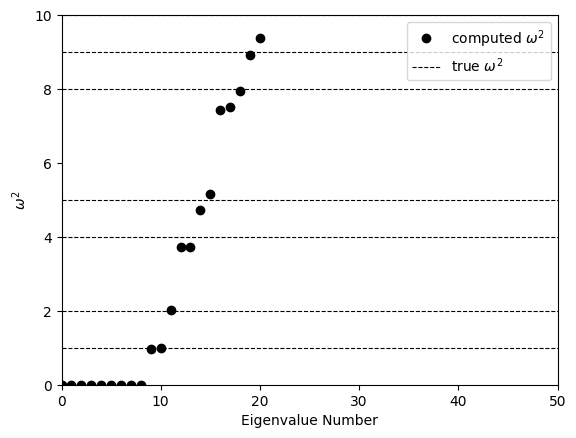

In [15]:
# Set the structured square mesh on (0, pi)
N = 4
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Nedelec space
Z = FunctionSpace(mesh, "N1curl", 1)

# Set zero tangential component
bcs = [DirichletBC(Z, Constant((0,0)), "on_boundary")]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
# plt.title(r"$N=4$")
plt.legend()
plt.savefig('Maxwell_Nedelec_N4.png', dpi=300, bbox_inches="tight")
plt.show()


  Eigenvalue approximations and residual norms for petsctools_21_ solve.


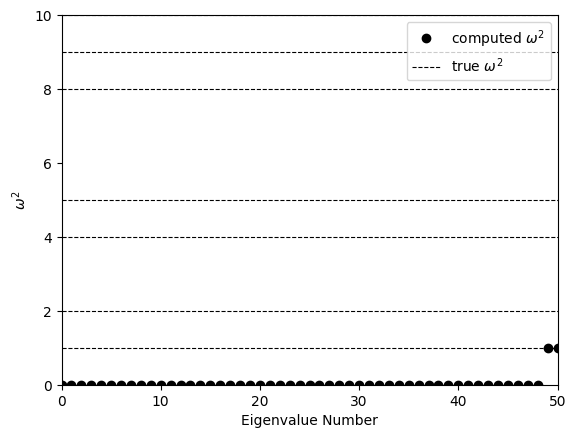

In [16]:
# Set the structured square mesh on (0, pi)
N = 8
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Nedelec space
Z = FunctionSpace(mesh, "N1curl", 1)

# Set zero tangential component
bcs = [DirichletBC(Z, Constant((0,0)), "on_boundary")]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
# plt.title(r"$N=8$")
plt.legend()
plt.savefig('Maxwell_Nedelec_N8.png', dpi=300, bbox_inches="tight")
plt.show()

  Eigenvalue approximations and residual norms for petsctools_23_ solve.
  1 EPS nconv=101 first unconverged value (error) 79.0398 (1.30668317e-10)


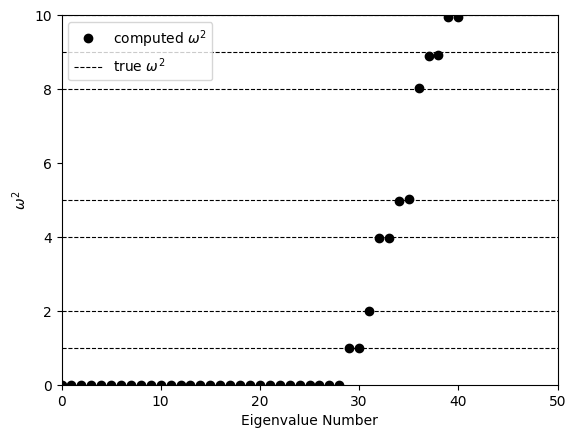

In [17]:
# Set the structured square mesh on (0, pi)
N = 16
mesh = SquareMesh(N, N, pi, quadrilateral = False)

# Set the Nedelec space
Z = FunctionSpace(mesh, "N1curl", 1)

# Set zero tangential component
bcs = [DirichletBC(Z, Constant((0,0)), "on_boundary")]

# Create the scalar rotation
def scalar_rot(E):
  # rot(E) = E2_x - E1_y
  return E[1].dx(0) - E[0].dx(1)

# Create the variational formulation
E = TrialFunction(Z)
F = TestFunction(Z)
a = inner(scalar_rot(E), scalar_rot(F))*dx
b = inner(E, F)*dx
problem = LinearEigenproblem(a, b, bcs, restrict=True)

# Set the solver parameters
sp = {"eps_gen_hermitian": None,  # solver parameters, passed to SLEPc
      "eps_type": "krylovschur",
      "eps_monitor": None,
      "eps_target_magnitude": None,
      "eps_target": 1,
      #"eps_view": None,  # uncomment to see the solver
      "st_type": "sinvert",
      "st_shift": 1,
      }


# Solve
solver = LinearEigensolver(problem, n_evals=100, solver_parameters=sp)
num_found = solver.solve()


# Pull the eigenvalues out
eigs = sorted(solver.eigenvalue(i) for i in range(num_found))

# Plot
plt.plot([i for i in range(num_found)], eigs,"ko", label = r"computed $\omega^2$")
plt.ylim(0, 10)
plt.xlim(0, 50)
plt.xlabel("Eigenvalue Number")
plt.ylabel(r"$\omega^2$")
for val in [1, 2, 4, 5, 8, 9]:
    plt.axhline(val, linestyle="--", linewidth=0.8, color = 'k')
plt.axhline(10, linestyle="--", linewidth=0.8, color = 'k', label = r"true $\omega^2$") # for the legend
# plt.title(r"$N=16$")
plt.legend()
plt.savefig('Maxwell_Nedelec_N16.png', dpi=300, bbox_inches="tight")
plt.show()